# Fuel Consumption pridict with **Polynomial Regresion** and **Simple and Multiple Linear Regression** and **Random Forest Regressor**

## Import Libraries

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Load fuel consumption file

In [4]:
co2 = pd.read_csv('FuelConsumption.csv')

In [5]:
co2.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [6]:
co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [7]:
co2.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [8]:
co2.describe(include= 'object')

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
count,1067,1067,1067,1067,1067
unique,39,663,16,22,4
top,FORD,F150 FFV 4X4,MID-SIZE,A6,X
freq,90,8,178,222,514


In [9]:
label_encode = LabelEncoder()
fuel_type_labels = pd.DataFrame(label_encode.fit_transform(co2.FUELTYPE), columns= ['FUELTYPE'])
vehicle_class_labels = pd.DataFrame(label_encode.fit_transform(co2.VEHICLECLASS), columns= ['VEHICLECLASS'])
transmission_labels = pd.DataFrame(label_encode.fit_transform(co2.TRANSMISSION), columns= ['TRANSMISSION'])
new_labels_df = pd.concat((fuel_type_labels, vehicle_class_labels, transmission_labels), axis= 1)
new_labels_df.head()

,FUELTYPE,VEHICLECLASS,TRANSMISSION
0,3,0,10
1,3,0,20
2,3,0,17
3,3,11,11
4,3,11,11


In [10]:
new_labels_df.describe()

,FUELTYPE,VEHICLECLASS,TRANSMISSION
count,1067.000000,1067.000000,1067.000000
mean,2.269916,6.337395,9.670103
std,0.722374,5.095388,6.673143
min,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000
50%,2.000000,6.000000,11.000000
75%,3.000000,11.000000,13.000000
max,3.000000,15.000000,21.000000


In [11]:
new_co2_df = co2.drop(columns=['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'], axis= 1)

In [12]:
new_co2_df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [13]:
new_co2_df = pd.concat((new_labels_df, new_co2_df), axis= 1)

In [14]:
new_co2_df.head()

,FUELTYPE,VEHICLECLASS,TRANSMISSION,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,3,0,10,2.0,4,9.9,6.7,8.5,33,196
1,3,0,20,2.4,4,11.2,7.7,9.6,29,221
2,3,0,17,1.5,4,6.0,5.8,5.9,48,136
3,3,11,11,3.5,6,12.7,9.1,11.1,25,255
4,3,11,11,3.5,6,12.1,8.7,10.6,27,244


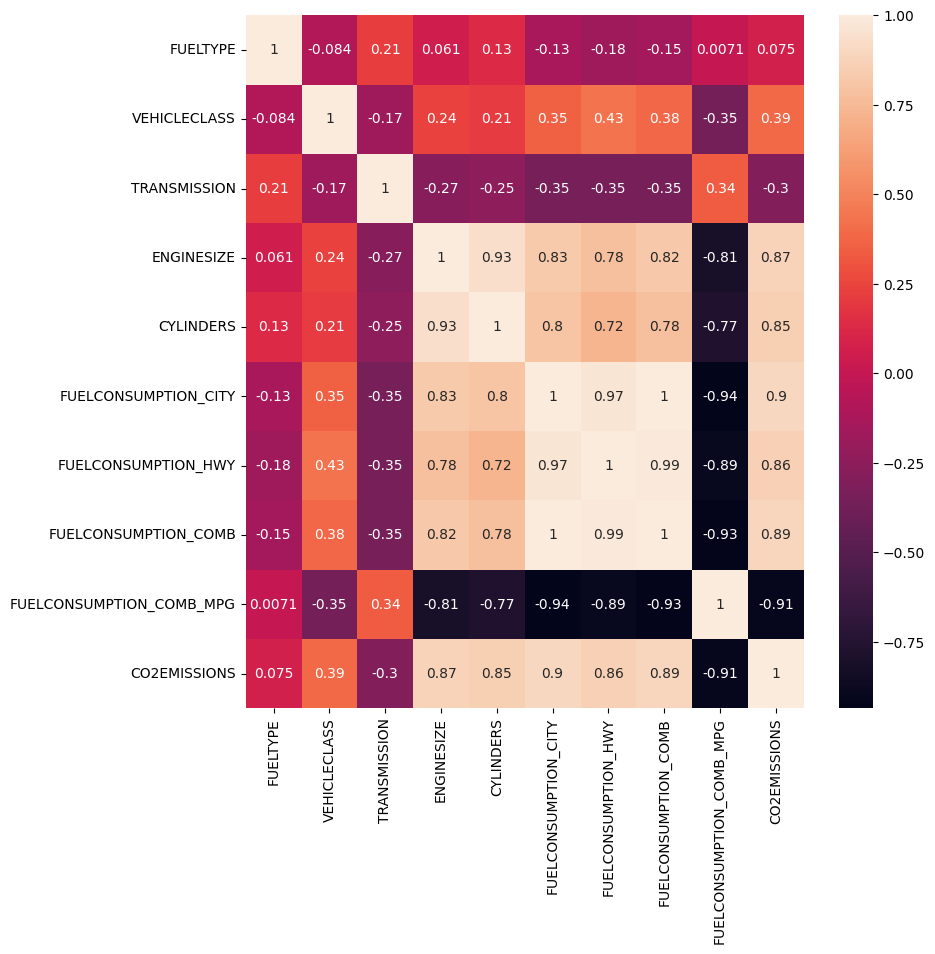

In [15]:
plt.figure(figsize= (9, 9))
sns.heatmap(new_co2_df.corr(), annot= True)
plt.show()

In [16]:
new_co2_df.corr(method= 'spearman')['CO2EMISSIONS'].sort_values(ascending= False)

,CO2EMISSIONS
CO2EMISSIONS,1.000000
FUELCONSUMPTION_COMB,0.953496
FUELCONSUMPTION_CITY,0.949859
FUELCONSUMPTION_HWY,0.936560
ENGINESIZE,0.889973
CYLINDERS,0.875330
VEHICLECLASS,0.393557
FUELTYPE,0.105436
TRANSMISSION,-0.290277
FUELCONSUMPTION_COMB_MPG,-0.952809


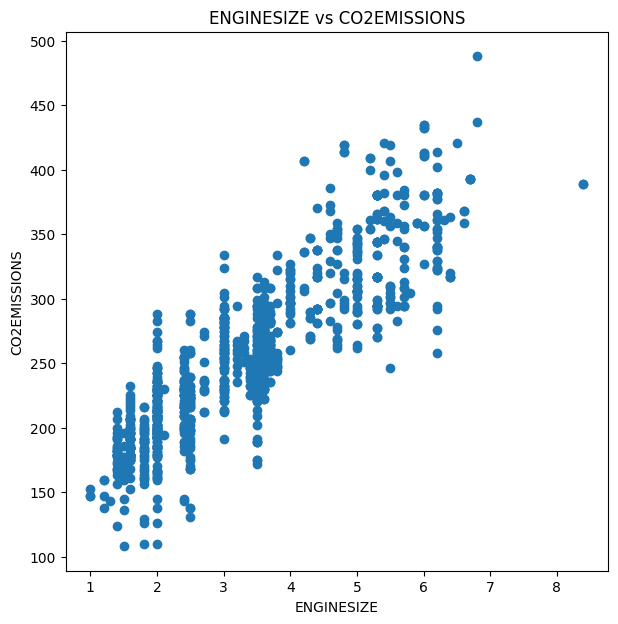

In [23]:
plt.figure(figsize= (7, 7))
plt.scatter(co2['ENGINESIZE'], co2['CO2EMISSIONS'])
plt.title('ENGINESIZE vs CO2EMISSIONS')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

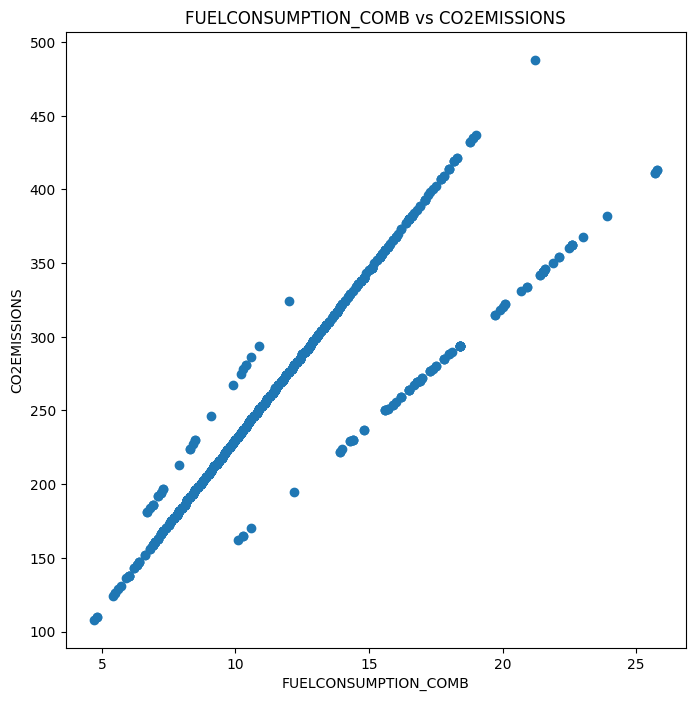

In [158]:
plt.figure(figsize= (8, 8))
plt.scatter(co2['FUELCONSUMPTION_COMB'], co2['CO2EMISSIONS'])
plt.title('FUELCONSUMPTION_COMB vs CO2EMISSIONS')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.show()

## Simple Linear Regression Model
**Feature Selection:** The **`FUELCONSUMPTION_COMB`** feature was chosen for this model due to its **strong positive correlation** with the target, making it the most suitable predictor for a simple linear model.


In [132]:
X = co2[['FUELCONSUMPTION_COMB']]
y = co2['CO2EMISSIONS']

## Train/Test Split
The data was split into training and testing sets after selecting **`FUELCONSUMPTION_COMB`** as the predictor variable.


In [135]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X, y, test_size= 0.2, random_state= 42)

## Training Simple Linear Model

In [28]:
simple_regr = LinearRegression()

In [136]:
simple_regr.fit(X_train_simple, y_train_simple)

LinearRegression()

In [137]:
print(f'Coef: {simple_regr.coef_[0]}\nIntercept: {simple_regr.intercept_}')

Coef: 16.180900781199195
Intercept: 69.10302617988444


In [138]:
y_train_hat = simple_regr.coef_[0] * X_train_simple[['FUELCONSUMPTION_COMB']] + simple_regr.intercept_
y_test_hat = simple_regr.coef_[0] * X_test_simple[['FUELCONSUMPTION_COMB']] + simple_regr.intercept_

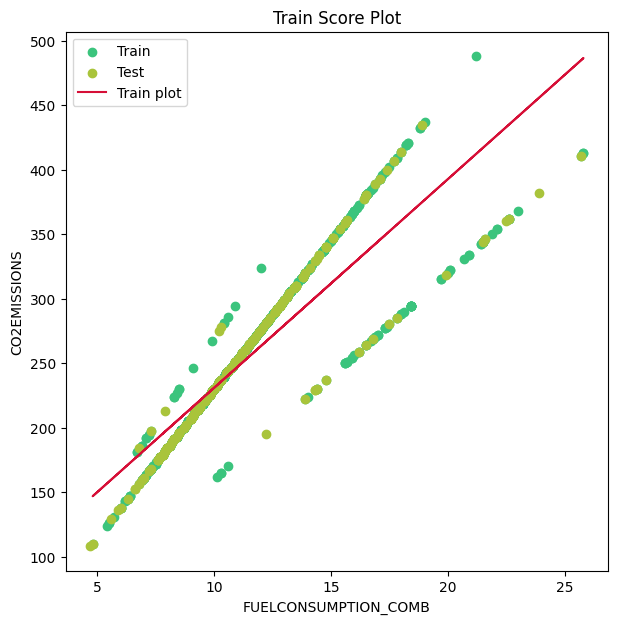

In [145]:
plt.figure(figsize= (7, 7))
plt.scatter(X_train_simple['FUELCONSUMPTION_COMB'], y_train_simple, c= '#3bc47d', label= 'Train')
plt.scatter(X_test_simple['FUELCONSUMPTION_COMB'], y_test_simple, c= '#a9c43b', label= 'Test')
plt.plot(X_train_simple['FUELCONSUMPTION_COMB'], y_train_hat, c='#d60f37', label= 'Train plot')
plt.title('Train Score Plot')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

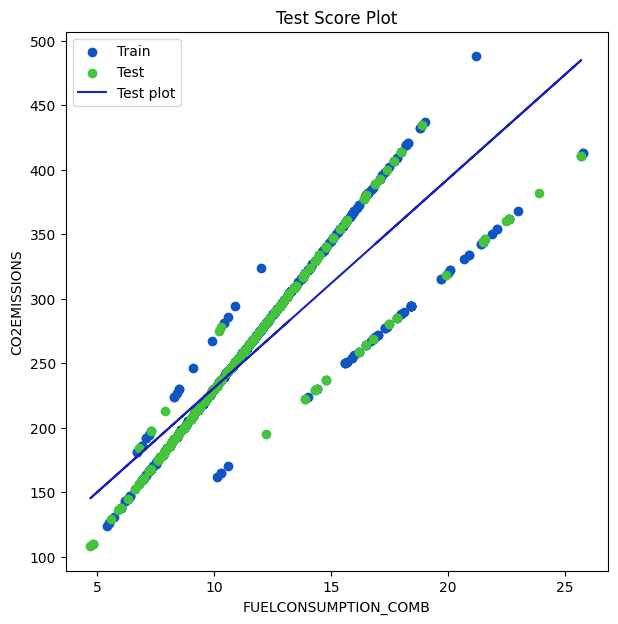

In [144]:
plt.figure(figsize= (7, 7))
plt.scatter(X_train_simple['FUELCONSUMPTION_COMB'], y_train_simple, c= '#1055c4', label= 'Train')
plt.scatter(X_test_simple['FUELCONSUMPTION_COMB'], y_test_simple, c= '#44c43b', label= 'Test')
plt.plot(X_test_simple['FUELCONSUMPTION_COMB'], y_test_hat, c= '#1a22b8', label= 'Test plot')
plt.title('Test Score Plot')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.legend()
plt.show()

## Evaluate Model Performance (MSE, MAE, $R^2$)


In [142]:
y_hat = simple_regr.predict(X_test_simple)

In [150]:
print(f'Mean Squared Error: {mean_squared_error(y_test_simple, y_hat)}\nMean Absolute Error: {mean_absolute_error(y_test_simple, y_hat)}\nR2: {simple_regr.score(X_test_simple[['FUELCONSUMPTION_COMB']], y_test_simple)* 100:.2f}%\nTrain Score: {simple_regr.score(X_train_simple[['FUELCONSUMPTION_COMB']], y_train_simple)* 100:.2f}%')

Mean Squared Error: 797.4346310097206
Mean Absolute Error: 20.441911472549577
R2: 80.71%
Train Score: 79.27%


# Multiple Linear Regression

## Use the Features with the Highest Correlation


In [151]:
X = new_co2_df[['FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB_MPG']]
y = new_co2_df['CO2EMISSIONS']

## Split Dataset into Train and Test Sets

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

##  Training **Multiple Linear Regression**

In [153]:
mult_regr = LinearRegression()

In [154]:
mult_regr.fit(X_train, y_train)

LinearRegression()

In [155]:
print(f'Coefficients: {mult_regr.coef_}\nIntercept: {mult_regr.intercept_}')

Coefficients: [ 21.86697334 -13.00156667  -5.47215573   8.96115125   7.24023686
  -4.03446041]
Intercept: 262.5721608698736


## Evaluate Model Performance (MSE, MAE, $R^2$)


In [156]:
y_hat = mult_regr.predict(X_test)

In [157]:
print(f'Mean squared Error: {mean_squared_error(y_test, y_hat)}\nMean Absolute Error: {mean_absolute_error(y_test, y_hat)}\nR2: {mult_regr.score(X_test, y_test) * 100:.2f}%')

Mean squared Error: 399.41868891442715
Mean Absolute Error: 12.90135933801832
R2: 90.34%
